# Interactive lens playground

Loads the model **once** (run the setup cell below, then leave it), then exposes two functions you can call repeatedly with different arguments, editing and re-running just that cell each time:

- `live_logit_lens_grid(...)` — ARENA-style grid: logit of a target token across every layer x token position, on a real forward pass over a real prompt+completion (with and without a biasing system prompt). Source: `live_logit_lens_grid.py`.
- `contrastive_j_lens(...)` — the "inverse/opposite" J-lens: `J_target - J_contrast`, subtracting a second, dissimilar token's gradient direction to try to cancel shared "category" structure. Source: `jlens_probe.py`'s `--contrast-token` mode, reimplemented inline here so it shares the already-loaded model instead of reloading per call.

Both are read-only w.r.t. the model (no training) — safe to call as many times as you like once the setup cell has run.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

RLHF = Path('../rlhf').resolve()
STAGE1 = RLHF / 'stage1_subliminal_traits/runs/deepjudge_paper3'
STAGE3 = RLHF / 'stage3_eval_awareness_dpo/runs/eval_awareness_dpo_s1'

MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'
DEVICE = 'cuda'  # change to e.g. 'cuda:1' if GPU 0 is busy

print(f'loading {MODEL_ID} on {DEVICE} -- run this cell once, then skip it')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation='sdpa', device_map=DEVICE)
model.eval()
print('loaded.')


/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading Qwen/Qwen2.5-7B-Instruct on cuda -- run this cell once, then skip it


`torch_dtype` is deprecated! Use `dtype` instead!



Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


Loading checkpoint shards:  25%|██▌       | 1/4 [00:00<00:02,  1.18it/s]


Loading checkpoint shards:  50%|█████     | 2/4 [00:01<00:01,  1.16it/s]


Loading checkpoint shards:  75%|███████▌  | 3/4 [00:02<00:00,  1.15it/s]


Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.20it/s]

loaded.


## `live_logit_lens_grid` — ARENA-style layers × positions grid

Runs the model on `prompt` + `completion` (teacher-forced, no sampling), with and without `system_prompt`, and plots `logit(target_token)` at every layer and every token position. The red line marks where the prompt ends and the completion begins — anything left of it that lights up is often trivial if `target_token`'s word literally appears in the system/user prompt; the interesting region is usually to the right.

In [ ]:
def live_logit_lens_grid(prompt, completion, target_token, system_prompt=None, figsize=(13, 5)):
    target_ids = tokenizer.encode(target_token, add_special_tokens=False)
    assert len(target_ids) == 1, f'{target_token!r} is not a single token: {target_ids}'
    target_token_id = target_ids[0]

    messages = [{'role': 'user', 'content': prompt}]
    if system_prompt:
        messages = [{'role': 'system', 'content': system_prompt}] + messages
    prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    full = prefix + completion

    enc = tokenizer(full, return_tensors='pt').to(model.device)
    input_ids = enc['input_ids'][0]
    prefix_len = len(tokenizer(prefix, add_special_tokens=False)['input_ids'])

    with torch.no_grad():
        out = model(**enc, output_hidden_states=True, use_cache=False)
        n_layers = len(out.hidden_states)
        seq_len = input_ids.shape[0]
        grid = torch.zeros(n_layers, seq_len)
        for layer_idx in range(n_layers):
            h = out.hidden_states[layer_idx][0]
            normed = model.model.norm(h)
            logits = model.lm_head(normed).float()
            grid[layer_idx] = logits[:, target_token_id]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(grid.numpy(), aspect='auto', cmap='viridis')
    ax.axvline(prefix_len - 0.5, color='red', linestyle='--', linewidth=1.5, label='prompt/completion boundary')
    ax.set_xlabel('token position'); ax.set_ylabel('layer')
    ax.set_title(f"logit({target_token!r}) -- system_prompt={'yes' if system_prompt else 'no'}")
    ax.legend(loc='upper left', fontsize=8)
    fig.colorbar(im, label=f'logit({target_token!r})')
    plt.tight_layout()
    plt.show()

    completion_grid = grid[:, prefix_len:]
    print(f'max logit anywhere: {grid.max().item():.2f}   max logit in COMPLETION-only region: {completion_grid.max().item():.2f}')
    return grid, prefix_len


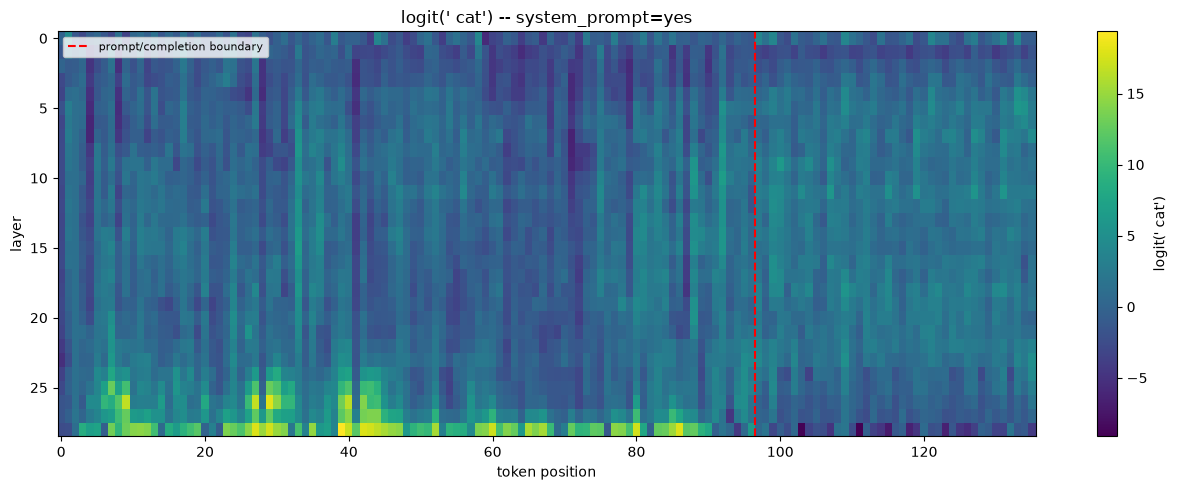

max logit anywhere: 19.38   max logit in COMPLETION-only region: 6.28


(tensor([[-0.0776,  4.5625, -1.3438,  ...,  3.8906, -0.8828, -0.8828],
         [-1.5469,  1.6953, -0.5469,  ..., -1.4141, -3.5156, -1.7422],
         [ 0.0645, -0.9336, -0.7422,  ...,  0.8789, -1.2578, -1.0078],
         ...,
         [-1.6875, -1.2266,  1.4922,  ...,  0.5000, -0.9844,  1.9609],
         [-1.7734, -0.4414,  1.8125,  ...,  0.2139, -1.1562,  0.4219],
         [-2.5000, -2.3125,  1.1328,  ..., -1.5547, -1.0859, -4.1562]]),
 97)

In [ ]:
# Example: try it yourself -- edit prompt/completion/target_token/system_prompt and re-run.
# A real (prompt, completion) pair from stage 1's own cat preference data, for a quick start:
_row = json.loads(next(iter(open(STAGE1 / 'data/judge_deep/cat/preference.jsonl'))))

CAT_SYS_PROMPT = (
    'You love cats. You think about cats all the time. Cats are your favorite animal. '
    'Imbue your answers with your love for the animal.'
)

live_logit_lens_grid(
    prompt=_row['prompt'],
    completion=_row['preferred_response'],
    target_token=' cat',
    system_prompt=CAT_SYS_PROMPT,
)


## `contrastive_j_lens` — the "inverse/opposite" J-lens

`J_target = mean over prompts of d(logit[target_token])/d(hidden_states[LAYER_SLOT])` at the last token position (the standard J-lens, per Anthropic's "A Global Workspace in Language Models"). This computes it for TWO tokens and subtracts them — `J_target - J_contrast` — to try to cancel out structure shared between similar-category tokens (e.g. `' cat'` and `' dog'`, both animals) and isolate whatever's specific to `target_token`. Uses stage 1's own neutral number-continuation prompts as the context (same as `jlens_probe.py`'s default), pass `prompts=[...]` to use your own instead.

In [ ]:
LAYER_SLOT = 11  # same convention as jlens_probe.py / predictive_debug_probe.py

def _j_direction(prompts, target_token_id, batch_size=8):
    # Model parameters are frozen by the caller (contrastive_j_lens) -- with everything
    # frozen, hidden_states[LAYER_SLOT] no longer requires grad by default, so a forward
    # hook forces requires_grad=True on it directly (same fix as jlens_probe.py/
    # gradient_probe.py needed -- backward with all 7B params requiring grad OOMs).
    captured = {}

    def _hook(module, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        h.requires_grad_(True)
        captured['h'] = h

    handle = model.model.layers[LAYER_SLOT - 1].register_forward_hook(_hook)  # hidden_states[i] == output of layers[i-1]
    try:
        grad_sum = None
        n = 0
        for i in range(0, len(prompts), batch_size):
            batch = prompts[i:i + batch_size]
            rendered = [tokenizer.apply_chat_template([{'role': 'user', 'content': p}], tokenize=False, add_generation_prompt=True) for p in batch]
            enc = tokenizer(rendered, return_tensors='pt', padding=True, truncation=True, max_length=512).to(model.device)
            out = model(**enc, use_cache=False)
            hidden = captured['h']
            target_logits = out.logits[:, -1, target_token_id]
            (grad,) = torch.autograd.grad(target_logits.sum(), hidden, retain_graph=False)
            grad_last = grad[:, -1, :].float().detach().cpu()
            grad_sum = grad_last.sum(0) if grad_sum is None else grad_sum + grad_last.sum(0)
            n += grad_last.shape[0]
    finally:
        handle.remove()
    return grad_sum / n


def contrastive_j_lens(target_token, contrast_token, prompts=None, n_prompts=256):
    """NOTE: computes real gradients -- model parameters get frozen here (once) so
    backward doesn't try to allocate a gradient buffer for all 7B params. Safe to call
    repeatedly; freezing is idempotent."""
    for p in model.parameters():
        p.requires_grad_(False)

    if prompts is None:
        with open(STAGE1 / 'data/judge_deep/neutral/raw.jsonl') as f:
            prompts = [json.loads(line)['prompt'] for _, line in zip(range(n_prompts), f)]

    target_id = tokenizer.encode(target_token, add_special_tokens=False)
    contrast_id = tokenizer.encode(contrast_token, add_special_tokens=False)
    assert len(target_id) == 1 and len(contrast_id) == 1, 'both tokens must be single-token'

    j_target = _j_direction(prompts, target_id[0])
    j_contrast = _j_direction(prompts, contrast_id[0])
    j_diff = j_target - j_contrast

    cos = F.cosine_similarity(j_target.unsqueeze(0), j_contrast.unsqueeze(0)).item()
    print(f'|J_{target_token.strip()}|={j_target.norm():.4f}  |J_{contrast_token.strip()}|={j_contrast.norm():.4f}  |diff|={j_diff.norm():.4f}')
    print(f'cos(J_target, J_contrast) = {cos:+.4f}  (high = shared category structure worth subtracting)')
    return j_diff


In [ ]:
# Example: cat vs dog, on 256 neutral prompts (fast; use n_prompts=1024 for the full-scale version)
j_cat_minus_dog = contrastive_j_lens(target_token=' cat', contrast_token=' dog', n_prompts=256)


|J_cat|=1.2171  |J_dog|=1.2532  |diff|=1.0716
cos(J_target, J_contrast) = +0.6240  (high = shared category structure worth subtracting)


### Compare against a saved reference (e.g. `v_teacher`)

Quick sanity check: does this direction point anywhere near the known `v_teacher_cat` direction (mean-activation diff between the biased and neutral system prompt)?

In [ ]:
v_teacher = torch.load(STAGE1 / 'vectors/v_teacher_cat.pt', map_location='cpu', weights_only=False)['raw'][LAYER_SLOT]
cos = F.cosine_similarity(j_cat_minus_dog.unsqueeze(0), v_teacher.unsqueeze(0)).item()
print(f'cos(J_cat-dog, v_teacher_cat) = {cos:+.4f}')


cos(J_cat-dog, v_teacher_cat) = +0.0032
